In [2]:
from typing import List,TypedDict
import time
import re


from langchain_community.document_loaders import PyPDFLoader,PyMuPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_mistralai import ChatMistralAI,MistralAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate


from pydantic import BaseModel

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv

from langchain_community.tools.tavily_search import TavilySearchResults



c:\Users\IshanBansal\AppData\Local\Programs\Python\Python311\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
load_dotenv()

True

In [4]:
docs = (
    PyPDFLoader("documents/book1.pdf").load() +
    PyPDFLoader("documents/book2.pdf").load() +
    PyPDFLoader("documents/book3.pdf").load()
)

In [5]:
len(docs)

2123

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150)
chunks = splitter.split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")
    
len(chunks)


6685

In [7]:
embeddings = MistralAIEmbeddings(model="mistral-embed")

In [8]:
vectorstore = FAISS.from_documents(chunks,embeddings)

In [9]:
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k":4})

In [10]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason : str

    strips : List[str]
    kept_strips : List[str]
    refined_context : str

    web_docs : List[Document]
    
    answer: str

In [11]:
def retiver(state: State):
    question = state["question"]
    retrieved_docs = retriever.invoke(question)
    return {"docs": retrieved_docs}

In [12]:
llm = ChatMistralAI(model="mistral-small-latest")

In [13]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [14]:
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def evaluator(state: State):
    q = state["question"]

    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # 5) for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > LOWER_TH:
            good.append(d)

    # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [15]:
def decompose(text : str):
    text = re.sub(r"\s+"," ",text)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state:State):
    question = state["question"]

    if state.get("verdict") == "CORRECT":
        context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()
    else:
        context = "\n\n".join(d.page_content for d in state["web_docs"]).strip()

    strips = decompose(context)

    kept: List[str] = []

    for s in strips:
        if filter_chain.invoke({"question": question, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n\n".join(kept).strip()

    return {"strips": strips, "kept_strips": kept, "refined_context": refined_context}
    

In [22]:
search_tool = TavilySearchResults(max_results=5)
def WebSearch(state:State):
    question = state["question"]
    results = search_tool.invoke(question)
    web_docs = []
    for r in results:
        title = r.get("title","")
        url = r.get("url","")
        content = r.get("snippet","") or r.get("content","")
        text = f"title :{title}\nUrl : {url}\n Content: {content}"
        web_docs.append(Document(page_content=text, metadata={"title": title, "url": url}))
    return {"web_docs": web_docs}

In [23]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

In [24]:

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "Websearch"
    else:
        return "ambiguous_node"

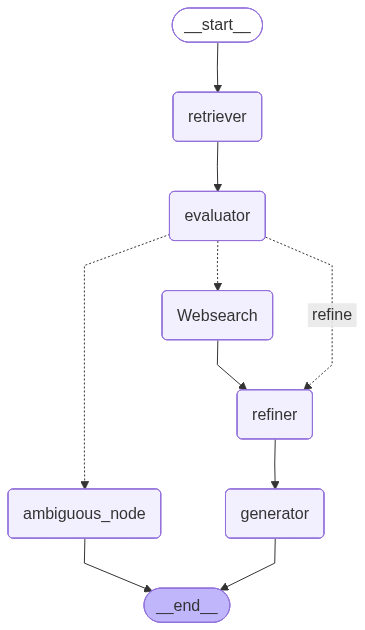

In [30]:
graph = StateGraph(State)

graph.add_node("retriever", retiver)
graph.add_node("generator", generate)
graph.add_node("refiner", refine)
graph.add_node("Websearch", WebSearch)
graph.add_node("ambiguous_node", ambiguous_node)
graph.add_node("evaluator", evaluator)

graph.add_edge(START, "retriever")
graph.add_edge("retriever", "evaluator")
graph.add_conditional_edges("evaluator", route_after_eval,{"refine":"refiner","Websearch":"Websearch","ambiguous_node":"ambiguous_node"})
graph.add_edge("Websearch", "refiner")
graph.add_edge("refiner", "generator")
graph.add_edge("generator", END)
graph.add_edge("ambiguous_node", END)


app = graph.compile()
app

In [27]:
res = app.invoke(
    {
        "question": "What is the situation in Ukraine as of June 2024?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 - **Russia-Iran Gas Deal**: Russia and Iran signed a memorandum on June 26 to supply Russian gas to Iran, amid reported disagreements between Russia and China over gas exports.
- **Ukraine’s Air Defense Crisis**: Ukraine faces a severe shortage of critical air defense missiles, limiting its ability to protect infrastructure from Russian strikes.
- **Military Advances & Strikes**:
  - Russian forces made marginal gains near Kupyansk.
  - Ukrainian forces struck Russian oil depots (June 28), a microelectronics plant, and a military unit (June 27–28).
- **Energy Infrastructure Damage**:
  - Russian strikes destroyed **50% of Ukraine’s power generation capacity** (9 GW out of 18 GW peak winter demand).
  - **80% of thermal power** and **one-third of hydroelectric plants** are destroyed.
- **Civilian Impact**:
  - Russian strikes killed **23 civilians in Dnipro** (June 24), **9 in Kyiv** (June 2

In [31]:
res = app.invoke(
    {
        "question": "bias vs tradeoff"
        "",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7.

OUTPUT:
 - **Bias vs. Variance**:
  - **Bias**: Measures the expected deviation from the true value of the function or parameter due to wrong assumptions (e.g., assuming data is linear when it's actually quadratic).
  - **Variance**: Measures the variability of the model's predictions, often due to overfitting.
- **Tradeoff**:
  - High bias (underfitting) → Model is too simple, misses patterns in the data.
  - High variance (overfitting) → Model fits noise in the training data, performs poorly on unseen data.
  - **Balancing**: Use techniques like cross-validation to navigate the tradeoff.
- **Generalization Error**: Sum of bias, variance, and irreducible error (noise).
  - Example: Small λ (regularization) → Low bias (good fit) but high variance.
  - Large λ → High bias (underfitting) but low variance.
